# Proyecto final - Clasificación de latidos ECG con MIT-BIH

**Asignatura:** Deep Learning para Series Temporales  
**Dataset utilizado:** ECG Heartbeat Categorization Dataset (`mitbih`)  
**Tarea:** Clasificación multiclase de latidos ECG en 5 categorías

Este trabajo aborda un problema de clasificación de series temporales a partir de señales de electrocardiograma ya segmentadas a nivel de latido. El objetivo es construir y comparar varios modelos capaces de asignar cada latido a una de las cinco clases disponibles en el subconjunto `mitbih`.

A lo largo del notebook se presenta la carga y verificación de los datos, un análisis exploratorio, varias iteraciones de modelado y una comparación final para seleccionar el mejor enfoque en función de métricas adecuadas para un problema desbalanceado.

## 1. Planteamiento del proyecto

### 1.1. Objetivo de la práctica

En este proyecto se ha escogido la opción de **clasificación** propuesta en el enunciado, trabajando con el subconjunto **`mitbih`** del dataset ECG. La tarea consiste en clasificar cada latido en una de las **cinco categorías clínicas** disponibles:

- **0 - N**: latido normal
- **1 - S**: latido supraventricular
- **2 - V**: latido ventricular
- **3 - F**: latido fusionado
- **4 - Q**: latido no clasificable o de tipo desconocido

### 1.2. Estrategia general del trabajo

La resolución del problema se ha estructurado en las siguientes fases:

1. carga y comprobación del dataset;
2. análisis exploratorio para entender la estructura de los datos y el reparto de clases;
3. definición de un preprocesado mínimo y justificado;
4. entrenamiento de varios modelos representativos de distintas familias;
5. comparación homogénea de resultados en validación;
6. selección del mejor modelo y evaluación final en test.

### 1.3. Justificación metodológica inicial

El enunciado pide un `main.ipynb` que recoja el trabajo completo realizado, incluyendo introducción, análisis exploratorio, iteraciones y selección del mejor modelo. Por ello, el notebook no se limita a entrenar un único modelo, sino que documenta varias alternativas razonables para este tipo de problema.

Además, se ha optado por una implementación basada en herramientas ampliamente utilizadas como `pandas`, `scikit-learn` y `tensorflow`, con el objetivo de mantener la práctica reproducible y fácil de ejecutar.

## 2. Configuración e imports

En esta sección se definen las dependencias, la semilla aleatoria y algunos parámetros generales de ejecución.

Se fija una semilla para mejorar la reproducibilidad del experimento y se incluye un modo `FAST_RUN` pensado únicamente para pruebas rápidas. Para la ejecución final del proyecto, lo adecuado es mantener `FAST_RUN = False`.

In [29]:
# =========================
# Configuración general
# =========================
FAST_RUN = False
SEED = 42

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# TensorFlow / Keras
try:
    import tensorflow as tf
except Exception:
    import sys
    !{sys.executable} -m pip install -q tensorflow
    import tensorflow as tf

from tensorflow.keras import layers, models, callbacks

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.20.0
NumPy: 2.1.2
Pandas: 2.2.3


## 3. Obtención y carga de datos

### 3.1. Ficheros necesarios

Para reproducir este proyecto se requieren al menos los siguientes archivos del dataset:

- `mitbih_train.csv`
- `mitbih_test.csv`

### 3.2. Estrategia de carga

El notebook intenta localizar automáticamente estos ficheros en varias rutas habituales del entorno de trabajo. Si no se encuentran, se lanza un error explícito para evitar ejecuciones ambiguas o silenciosamente incorrectas.

Se ha optado por una carga local de archivos, sin depender de autenticaciones externas ni de descargas en tiempo de ejecución, con el fin de hacer la práctica más estable y más sencilla de corregir.

In [30]:
def build_candidate_dirs():
    cwd = Path.cwd().resolve()
    candidate_dirs = [
        cwd,
        cwd / "data",
        cwd / "data" / "heartbeat",
        cwd / "DLTEMP" / "practica final",
        cwd / "DLTEMP" / "practica final" / "data",
        cwd / "DLTEMP" / "practica final" / "data" / "heartbeat",
        Path("/content"),
        Path("/content/data"),
        Path("/content/data/heartbeat"),
        Path("/kaggle/input/heartbeat"),
        Path("/kaggle/input/ecg-heartbeat-categorization-dataset"),
        Path("/mnt/data"),
    ]

    unique_dirs = []
    seen = set()
    for d in candidate_dirs:
        d = d.resolve()
        if d not in seen:
            unique_dirs.append(d)
            seen.add(d)
    return unique_dirs

def find_file(filename: str, candidate_dirs=None):
    if candidate_dirs is None:
        candidate_dirs = build_candidate_dirs()
    for d in candidate_dirs:
        p = d / filename
        if p.exists():
            return p
    return None

train_path = find_file("mitbih_train.csv")
test_path = find_file("mitbih_test.csv")

if train_path is None or test_path is None:
    raise FileNotFoundError(
        "No se han encontrado `mitbih_train.csv` y `mitbih_test.csv`. "
        "Colócalos en la carpeta actual, en `data/heartbeat/` o en una ruta estándar del entorno."
    )

train_path, test_path

(WindowsPath('C:/Users/usuario/Desktop/Master Deep Learning/DLTEMP/practica final/mitbih_train.csv'),
 WindowsPath('C:/Users/usuario/Desktop/Master Deep Learning/DLTEMP/practica final/mitbih_test.csv'))

In [31]:
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

feature_cols = [f"t_{i}" for i in range(train_df.shape[1] - 1)]
columns = feature_cols + ["label"]

train_df.columns = columns
test_df.columns = columns

print("Shape train:", train_df.shape)
print("Shape test :", test_df.shape)
train_df.head()

Shape train: (87554, 188)
Shape test : (21892, 188)


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_178,t_179,t_180,t_181,t_182,t_183,t_184,t_185,t_186,label
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Verificación inicial del dataset

Antes de entrenar modelos, conviene comprobar que la representación de los datos es coherente con lo esperado para un problema de clasificación temporal ya preparado.

En particular, interesa verificar:
- que todas las señales tienen la misma longitud;
- que no hay valores faltantes;
- que el número de clases coincide entre entrenamiento y test.

Estas comprobaciones permiten justificar que no son necesarias etapas adicionales de imputación, resegmentación o alineamiento temporal en esta práctica.

In [32]:
print("Número de columnas de señal:", len(feature_cols))
print("Valores faltantes en train:", int(train_df.isna().sum().sum()))
print("Valores faltantes en test :", int(test_df.isna().sum().sum()))
print("Número de clases train    :", train_df['label'].nunique())
print("Número de clases test     :", test_df['label'].nunique())

train_df.describe().T.head()

Número de columnas de señal: 187
Valores faltantes en train: 0
Valores faltantes en test : 0
Número de clases train    : 5
Número de clases test     : 5


,count,mean,std,min,25%,50%,75%,max
t_0,87554.0,0.890360,0.240909,0.0,0.921922,0.991342,1.000000,1.0
t_1,87554.0,0.758160,0.221813,0.0,0.682486,0.826013,0.910506,1.0
t_2,87554.0,0.423972,0.227305,0.0,0.250969,0.429472,0.578767,1.0
t_3,87554.0,0.219104,0.206878,0.0,0.048458,0.166000,0.341727,1.0
t_4,87554.0,0.201127,0.177058,0.0,0.082329,0.147878,0.258993,1.0


## 5. Etiquetas de clase

En el subconjunto `mitbih`, las etiquetas se codifican en cinco clases:

- `0`: N
- `1`: S
- `2`: V
- `3`: F
- `4`: Q

Para facilitar la interpretación de los resultados, se añade una versión legible de estas etiquetas. Esto mejora especialmente la lectura de tablas, gráficos y matrices de confusión.

In [33]:
label_map = {
    0: "N (normal)",
    1: "S (supraventricular)",
    2: "V (ventricular)",
    3: "F (fusionado)",
    4: "Q (desconocido)",
}

train_df["label_name"] = train_df["label"].map(label_map)
test_df["label_name"] = test_df["label"].map(label_map)

train_df[["label", "label_name"]].drop_duplicates().sort_values("label")

,label,label_name
0,0.0,N (normal)
72471,1.0,S (supraventricular)
74694,2.0,V (ventricular)
80482,3.0,F (fusionado)
81123,4.0,Q (desconocido)


## 6. Análisis exploratorio de los datos (EDA)

### 6.1. Distribución de clases

El análisis exploratorio comienza estudiando el reparto de clases, ya que este aspecto condiciona tanto la elección de métricas como la interpretación de los resultados.

En este dataset existe un desbalanceo claro: la clase **N** concentra la mayor parte de las observaciones, mientras que otras como **S** y **F** son claramente minoritarias. Por este motivo, no es suficiente con observar únicamente la `accuracy`; será necesario complementar la evaluación con métricas más sensibles al comportamiento sobre clases minoritarias, como `macro-F1` y `balanced accuracy`.

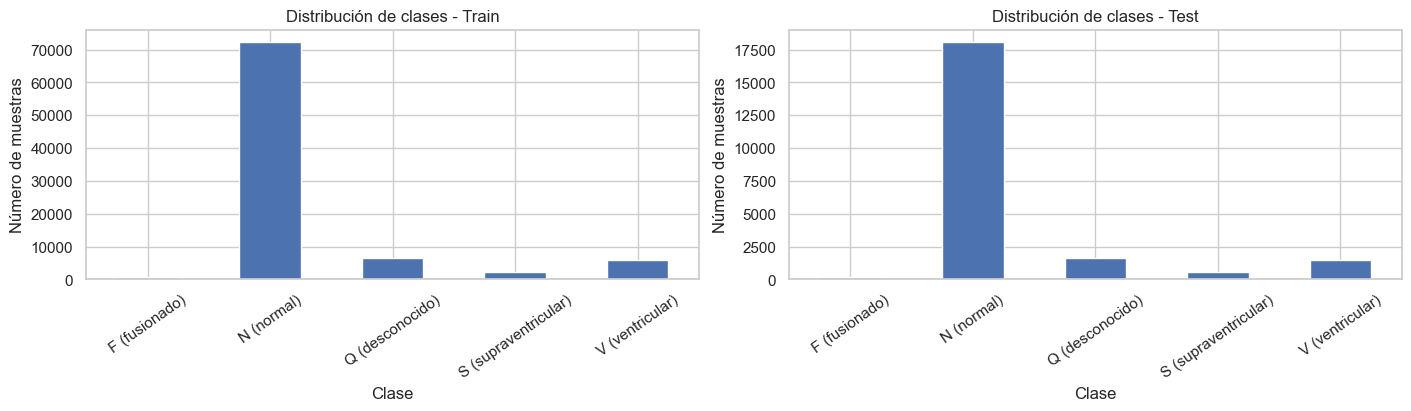

,train_n,test_n,train_pct,test_pct
label_name,,,,
F (fusionado),641,162,0.73,0.74
N (normal),72471,18118,82.77,82.76
Q (desconocido),6431,1608,7.35,7.35
S (supraventricular),2223,556,2.54,2.54
V (ventricular),5788,1448,6.61,6.61


In [34]:
class_counts_train = train_df["label_name"].value_counts().sort_index()
class_counts_test = test_df["label_name"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

class_counts_train.plot(kind="bar", ax=axes[0], title="Distribución de clases - Train")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Número de muestras")
axes[0].tick_params(axis="x", rotation=35)

class_counts_test.plot(kind="bar", ax=axes[1], title="Distribución de clases - Test")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Número de muestras")
axes[1].tick_params(axis="x", rotation=35)

plt.show()

pd.DataFrame({
    "train_n": class_counts_train,
    "test_n": class_counts_test,
    "train_pct": (class_counts_train / class_counts_train.sum() * 100).round(2),
    "test_pct": (class_counts_test / class_counts_test.sum() * 100).round(2),
})

### 6.2. Ejemplos de latidos por clase

A continuación se representan varios ejemplos de señales de cada clase para obtener una primera visión cualitativa del problema.

Este tipo de visualización permite comprobar si existen diferencias morfológicas apreciables entre categorías y anticipar, al menos de forma preliminar, qué clases podrían resultar más fáciles o más difíciles de separar.

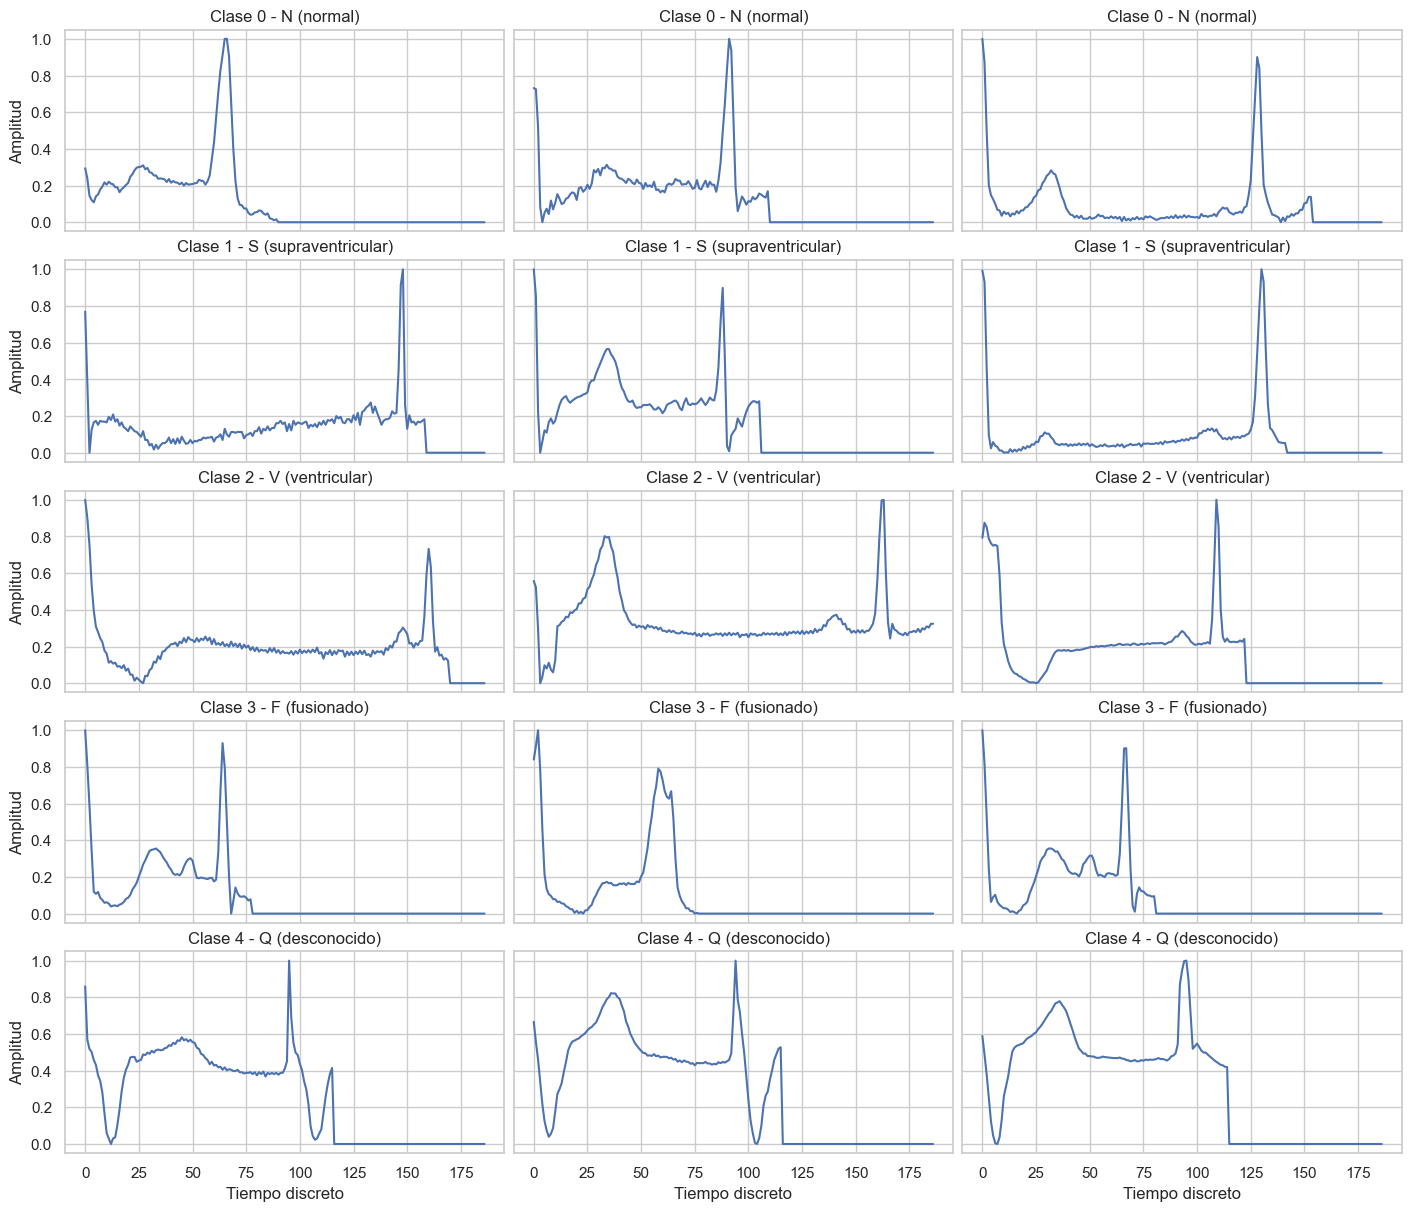

In [35]:
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(5, 3, figsize=(14, 12), sharex=True, sharey=True, constrained_layout=True)

for row, class_id in enumerate(sorted(label_map.keys())):
    class_rows = train_df[train_df["label"] == class_id]
    sampled_idx = rng.choice(class_rows.index, size=3, replace=False)
    for col, idx in enumerate(sampled_idx):
        signal = train_df.loc[idx, feature_cols].values.astype(float)
        axes[row, col].plot(signal)
        axes[row, col].set_title(f"Clase {class_id} - {label_map[class_id]}")
        if row == 4:
            axes[row, col].set_xlabel("Tiempo discreto")
        if col == 0:
            axes[row, col].set_ylabel("Amplitud")

plt.show()

### 6.3. Latido medio por clase

Además de visualizar ejemplos individuales, resulta útil representar el latido medio de cada categoría.

Aunque esta representación no recoge toda la variabilidad interna de cada clase, sí ofrece una referencia rápida sobre las tendencias globales de forma y puede ayudar a identificar diferencias morfológicas relevantes entre grupos.

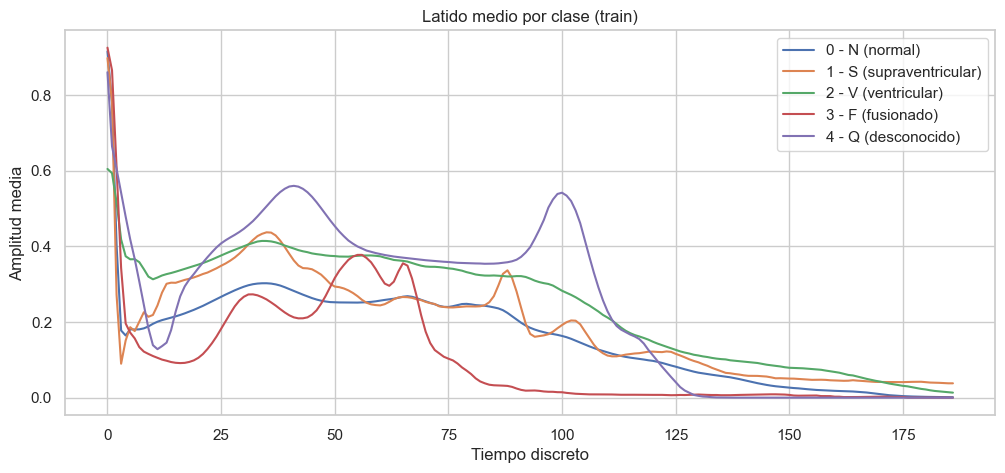

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))

for class_id in sorted(label_map.keys()):
    mean_wave = train_df.loc[train_df["label"] == class_id, feature_cols].mean(axis=0).values
    ax.plot(mean_wave, label=f"{class_id} - {label_map[class_id]}")

ax.set_title("Latido medio por clase (train)")
ax.set_xlabel("Tiempo discreto")
ax.set_ylabel("Amplitud media")
ax.legend()
plt.show()

### 6.4. Resumen interpretativo del EDA

El análisis exploratorio confirma que se trata de un problema de clasificación multiclase con un desbalanceo notable, dominado por la clase **N (normal)**. Esta situación hace que métricas globales como la `accuracy` resulten insuficientes por sí solas, ya que podrían ocultar un rendimiento deficiente en las clases minoritarias.

Desde el punto de vista de la señal, los ejemplos visualizados y los latidos medios por clase sugieren que existen patrones morfológicos diferenciables, especialmente en algunas categorías como **V** o **Q**. Sin embargo, también se aprecia una mayor variabilidad en clases minoritarias como **S** y **F**, lo que anticipa una dificultad mayor para su clasificación.

En conjunto, el EDA respalda dos decisiones metodológicas para el resto del notebook: mantener una evaluación sensible al desbalanceo y comparar enfoques de complejidad distinta, desde modelos base hasta modelos no lineales y arquitecturas neuronales.

## 7. Preparación de datos y particiones

### 7.1. Decisiones de preprocesado

El preprocesado aplicado en este trabajo es intencionadamente contenido.

- Se mantiene el conjunto `test` original exclusivamente para la evaluación final.
- A partir del `train` original se genera una partición de validación estratificada.
- No se realiza imputación ni remuestreo temporal, ya que los datos ya están segmentados, tienen longitud fija y no contienen valores faltantes.
- Se aplica `StandardScaler` únicamente en los modelos sensibles a escala, como la regresión logística y el MLP.
- En los modelos entrenables se incorporan pesos por clase para reducir el impacto del desbalanceo.

### 7.2. Métrica principal de selección

La métrica principal utilizada para comparar modelos es **`macro-F1`** en validación.

Esta elección está justificada por el fuerte desbalanceo del dataset: al promediar el rendimiento por clase, `macro-F1` evita que la clase mayoritaria oculte el comportamiento real del modelo sobre las categorías minoritarias.

In [37]:
X_train_full = train_df[feature_cols].values.astype(np.float32)
y_train_full = train_df["label"].values.astype(int)

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df["label"].values.astype(int)

if FAST_RUN:
    # Submuestreo estratificado para pruebas rápidas
    from sklearn.model_selection import StratifiedShuffleSplit

    sss = StratifiedShuffleSplit(n_splits=1, train_size=12000, random_state=SEED)
    idx_sub, _ = next(sss.split(X_train_full, y_train_full))
    X_train_full = X_train_full[idx_sub]
    y_train_full = y_train_full[idx_sub]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full,
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (74420, 187) (74420,)
Val  : (13134, 187) (13134,)
Test : (21892, 187) (21892,)


In [38]:
# Escalado para modelos lineales / MLP
scaler_raw = StandardScaler()
X_train_scaled = scaler_raw.fit_transform(X_train)
X_val_scaled = scaler_raw.transform(X_val)
X_test_scaled = scaler_raw.transform(X_test)

# Tensores para CNN
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
class_weight_dict

{0: 0.24162337662337663,
 1: 7.879301217575437,
 2: 3.0252032520325205,
 3: 27.310091743119266,
 4: 2.7230150018294914}

## 8. Funciones auxiliares de evaluación

Para garantizar una comparación homogénea entre todas las iteraciones, se definen funciones comunes de evaluación y visualización.

Estas funciones calculan las mismas métricas para todos los modelos y permiten registrar sus resultados de forma consistente, facilitando después la comparación en validación y en test.

In [39]:
from IPython.display import display, Markdown

results = []

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def register_result(model_name, split_name, y_true, y_pred):
    m = compute_metrics(y_true, y_pred)
    row = {"modelo": model_name, "split": split_name}
    row.update(m)
    results.append(row)
    return row

def plot_confusion(y_true, y_pred, title, labels=None, figsize=(6, 5)):
    if labels is None:
        labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    fig, ax = plt.subplots(figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=[label_map[int(i)] for i in labels],
        cmap="Blues",
        ax=ax,
        xticks_rotation=35,
        colorbar=False,
    )
    ax.set_title(title)
    plt.show()

def print_report(y_true, y_pred):
    print(classification_report(
        y_true,
        y_pred,
        target_names=[label_map[i] for i in sorted(label_map.keys())],
        zero_division=0,
    ))

## 9. Iteración 0 - Baseline trivial

### Idea

Como referencia mínima, se utiliza un clasificador que predice siempre la clase mayoritaria.

### Justificación

Este baseline permite comprobar hasta qué punto el desbalanceo del dataset puede inflar artificialmente la `accuracy`. Si un modelo más elaborado no supera con claridad esta referencia en métricas más robustas, su utilidad real sería cuestionable.

In [40]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_val_pred_dummy = dummy_clf.predict(X_val)
dummy_metrics = register_result("Dummy - clase mayoritaria", "val", y_val, y_val_pred_dummy)
pd.DataFrame([dummy_metrics]).round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,Dummy - clase mayoritaria,val,0.8277,0.2,0.1655,0.2,0.1811


## 10. Iteración 1 - Regresión logística multinomial sobre la serie cruda escalada

### Idea

En esta primera aproximación se entrena una regresión logística multinomial directamente sobre los 187 puntos de cada latido, una vez escalados.

### Justificación

Este modelo actúa como baseline lineal fuerte y sencillo. Permite medir cuánto del problema puede resolverse mediante fronteras de decisión aproximadamente lineales y sirve como punto de comparación frente a modelos no lineales y enfoques más complejos.

In [41]:
logreg = LogisticRegression(
    max_iter=500,
    multi_class="multinomial",
    solver="lbfgs",
    class_weight="balanced",
    n_jobs=None,
    random_state=SEED,
)
logreg.fit(X_train_scaled, y_train)

y_val_pred_logreg = logreg.predict(X_val_scaled)
logreg_metrics = register_result("LogReg multinomial", "val", y_val, y_val_pred_logreg)
pd.DataFrame([logreg_metrics]).round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,LogReg multinomial,val,0.6776,0.7787,0.4488,0.7787,0.4857


## 11. Iteración 2 - Random Forest sobre *features* temporales manuales

### Idea

En esta iteración cada latido se transforma en un conjunto reducido de características estadísticas y temporales, sobre las que se entrena un `RandomForest`.

### Justificación

Este enfoque representa la familia de métodos basada en extracción de características. Su interés radica en comprobar si un resumen manual bien diseñado de la señal contiene suficiente información discriminativa como para competir con modelos que trabajan directamente sobre la forma completa del latido.

In [42]:
def extract_time_features(X):
    X = np.asarray(X, dtype=np.float32)
    # Evitar divisiones problemáticas en señales degeneradas
    eps = 1e-8

    feats = pd.DataFrame({
        "mean": X.mean(axis=1),
        "std": X.std(axis=1),
        "min": X.min(axis=1),
        "max": X.max(axis=1),
        "median": np.median(X, axis=1),
        "q25": np.quantile(X, 0.25, axis=1),
        "q75": np.quantile(X, 0.75, axis=1),
        "ptp": np.ptp(X, axis=1),
        "energy": np.sum(X**2, axis=1),
        "mean_abs": np.mean(np.abs(X), axis=1),
        "argmax": np.argmax(X, axis=1),
        "argmin": np.argmin(X, axis=1),
        "signal_length": np.sum(np.abs(np.diff(X, axis=1)), axis=1),
        "zero_crossings": np.sum(np.diff(np.signbit(X), axis=1), axis=1),
        "skew": skew(X, axis=1, bias=False, nan_policy="omit"),
        "kurtosis": kurtosis(X, axis=1, fisher=True, bias=False, nan_policy="omit"),
    }).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return feats

X_train_feat = extract_time_features(X_train)
X_val_feat = extract_time_features(X_val)
X_test_feat = extract_time_features(X_test)

X_train_feat.head()

,mean,std,min,max,median,q25,q75,ptp,energy,mean_abs,argmax,argmin,signal_length,zero_crossings,skew,kurtosis
0,0.162387,0.175627,0.0,1.0,0.137931,0.000000,0.267241,1.0,10.699075,0.162387,0,97,5.103448,0,1.698217,4.917481
1,0.067435,0.161425,0.0,1.0,0.023004,0.000000,0.048714,1.0,5.723199,0.067435,0,88,4.220569,0,4.285594,19.739698
2,0.176905,0.224562,0.0,1.0,0.000000,0.000000,0.333333,1.0,15.282328,0.176905,0,74,4.826558,0,1.116723,0.964426
3,0.400353,0.242682,0.0,1.0,0.457045,0.350515,0.532646,1.0,40.986053,0.400353,119,122,5.398625,0,-0.518338,-0.478962
4,0.295457,0.274615,0.0,1.0,0.426168,0.000000,0.523364,1.0,30.426416,0.295457,1,101,4.783177,0,0.170566,-1.213504


In [43]:
rf = RandomForestClassifier(
    n_estimators=300 if not FAST_RUN else 120,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=SEED,
)
rf.fit(X_train_feat, y_train)

y_val_pred_rf = rf.predict(X_val_feat)
rf_metrics = register_result("RandomForest + features", "val", y_val, y_val_pred_rf)
pd.DataFrame([rf_metrics]).round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,RandomForest + features,val,0.9653,0.8026,0.9059,0.8026,0.8468


## 12. Iteración 3 - MLP sobre la señal cruda escalada

### Idea

A continuación se prueba una red neuronal densa que toma como entrada la señal cruda escalada.

### Justificación

El MLP introduce no linealidad y mayor capacidad de representación que los modelos clásicos anteriores, pero sin explotar explícitamente la estructura local de la señal. Por ello, constituye una iteración intermedia útil entre los modelos tabulares y una arquitectura convolucional.

In [44]:
BATCH_SIZE = 256 if not FAST_RUN else 128
EPOCHS = 30 if not FAST_RUN else 8

def build_mlp(input_dim: int, n_classes: int = 5):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.30),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

mlp = build_mlp(X_train_scaled.shape[1], len(label_map))
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5 if not FAST_RUN else 3,
    restore_best_weights=True,
)

history_mlp = mlp.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    verbose=0,
    callbacks=[early_stop],
)

y_val_pred_mlp = np.argmax(mlp.predict(X_val_scaled, verbose=0), axis=1)
mlp_metrics = register_result("MLP", "val", y_val, y_val_pred_mlp)
pd.DataFrame([mlp_metrics]).round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,MLP,val,0.9038,0.9279,0.6573,0.9279,0.7159


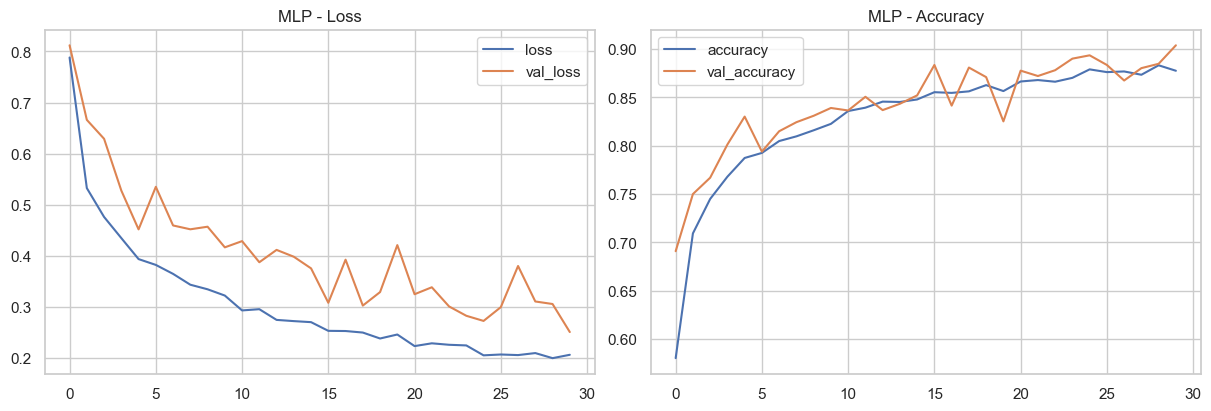

In [45]:
def plot_history(history, title="Training history"):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
    hist[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title} - Loss")
    hist[[c for c in hist.columns if "accuracy" in c]].plot(ax=axes[1], title=f"{title} - Accuracy")
    plt.show()

plot_history(history_mlp, title="MLP")

## 13. Iteración 4 - CNN 1D sobre la señal cruda

### Idea

En esta última iteración se entrena una red convolucional 1D para aprender patrones locales directamente a partir de la forma del latido.

### Justificación

Las convoluciones 1D son una elección natural en problemas de clasificación de series temporales, ya que permiten capturar estructuras locales y combinaciones jerárquicas de patrones. En este trabajo se emplea una arquitectura compacta, suficientemente expresiva para la tarea y a la vez fácil de reproducir.

In [46]:
def build_cnn1d(input_shape, n_classes: int = 5):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn = build_cnn1d((X_train_cnn.shape[1], 1), len(label_map))
early_stop_cnn = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6 if not FAST_RUN else 3,
    restore_best_weights=True,
)

history_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    verbose=0,
    callbacks=[early_stop_cnn],
)

y_val_pred_cnn = np.argmax(cnn.predict(X_val_cnn, verbose=0), axis=1)
cnn_metrics = register_result("CNN 1D", "val", y_val, y_val_pred_cnn)
pd.DataFrame([cnn_metrics]).round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,CNN 1D,val,0.907,0.8914,0.6555,0.8914,0.7142


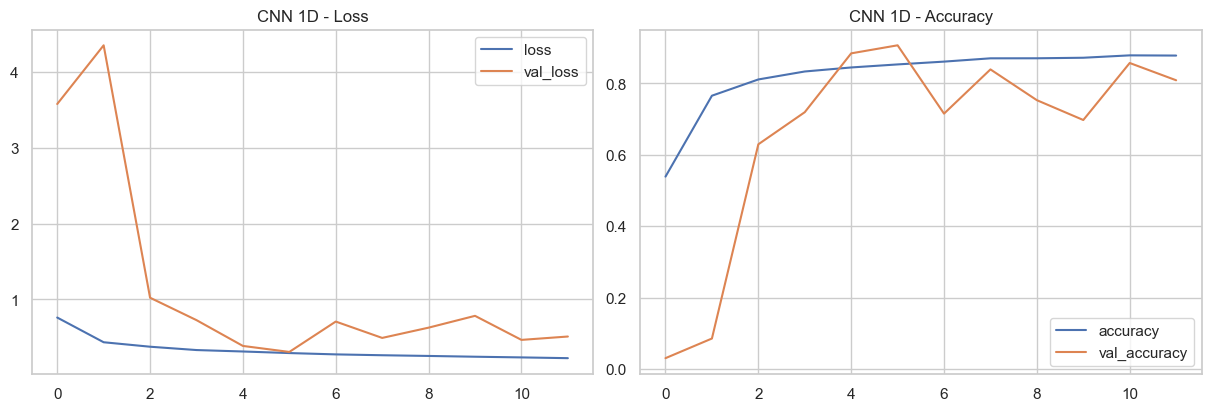

In [47]:
plot_history(history_cnn, title="CNN 1D")

## 14. Comparativa de iteraciones y selección del mejor modelo

### Criterio de selección

La selección del mejor modelo se realiza en función de **`macro-F1` en validación**, utilizando `balanced accuracy` y `accuracy` como métricas complementarias de apoyo.

Dado el desbalanceo del problema, este criterio resulta más informativo que elegir únicamente por `accuracy`, ya que penaliza mejor los fallos sobre clases minoritarias.

In [48]:
results_df = pd.DataFrame(results)
val_results = (
    results_df[results_df["split"] == "val"]
    .sort_values(["macro_f1", "balanced_accuracy", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

val_results.round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,RandomForest + features,val,0.9653,0.8026,0.9059,0.8026,0.8468
1,MLP,val,0.9038,0.9279,0.6573,0.9279,0.7159
2,CNN 1D,val,0.9070,0.8914,0.6555,0.8914,0.7142
3,LogReg multinomial,val,0.6776,0.7787,0.4488,0.7787,0.4857
4,Dummy - clase mayoritaria,val,0.8277,0.2000,0.1655,0.2000,0.1811


In [49]:
best_model_name = val_results.iloc[0]["modelo"]
display(Markdown(f"### Mejor modelo en validación: **{best_model_name}**"))

### Mejor modelo en validación: **RandomForest + features**

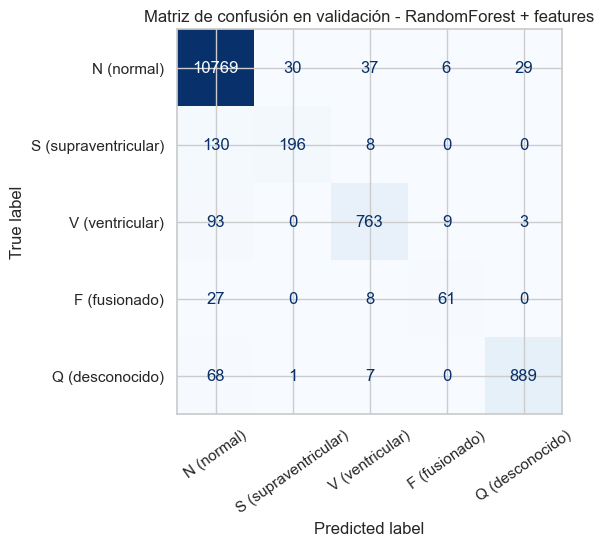

                      precision    recall  f1-score   support

          N (normal)       0.97      0.99      0.98     10871
S (supraventricular)       0.86      0.59      0.70       334
     V (ventricular)       0.93      0.88      0.90       868
       F (fusionado)       0.80      0.64      0.71        96
     Q (desconocido)       0.97      0.92      0.94       965

            accuracy                           0.97     13134
           macro avg       0.91      0.80      0.85     13134
        weighted avg       0.96      0.97      0.96     13134



In [50]:
val_pred_dict = {
    "Dummy - clase mayoritaria": y_val_pred_dummy,
    "LogReg multinomial": y_val_pred_logreg,
    "RandomForest + features": y_val_pred_rf,
    "MLP": y_val_pred_mlp,
    "CNN 1D": y_val_pred_cnn,
}

plot_confusion(
    y_val,
    val_pred_dict[best_model_name],
    title=f"Matriz de confusión en validación - {best_model_name}"
)
print_report(y_val, val_pred_dict[best_model_name])

## 15. Discusión metodológica de la selección

### Lectura de la comparativa

La comparación entre iteraciones muestra comportamientos claramente distintos según la familia de modelos considerada. El clasificador trivial confirma que la `accuracy` aislada puede resultar engañosa en este problema, ya que obtiene un valor elevado apoyándose casi exclusivamente en la clase mayoritaria y presenta un rendimiento muy pobre en términos de equilibrio entre clases.

La regresión logística mejora de forma clara esa referencia inicial, pero sigue siendo limitada para capturar la complejidad de la señal ECG a partir de la serie cruda. Por su parte, los modelos neuronales mejoran de forma notable la sensibilidad global hacia clases minoritarias, como refleja su `balanced_accuracy`, aunque en esta configuración concreta no alcanzan el mejor `macro-F1`.

El modelo **RandomForest + features** obtiene el mejor valor de `macro-F1` en validación, además de una `accuracy` alta y un comportamiento competitivo en el resto de métricas. Esto sugiere que, en este experimento, la extracción manual de características temporales proporciona una representación suficientemente informativa para que un modelo de tipo árbol separe bien las distintas clases.

### Decisión adoptada

Dado que el conjunto presenta un desbalanceo importante, se adopta `macro-F1` como criterio principal de selección, al ponderar por igual el rendimiento en todas las clases. Bajo este criterio, el modelo seleccionado para la evaluación final es **RandomForest + features**.

Conviene señalar, no obstante, que esta conclusión debe interpretarse en el contexto de los modelos y configuraciones efectivamente evaluados en el notebook. Es decir, el resultado obtenido no implica que un enfoque de deep learning sea necesariamente inferior en términos generales, sino que en esta comparación concreta el enfoque basado en características manuales ofrece el mejor rendimiento global.

## 16. Evaluación final en el conjunto de test

Una vez seleccionado el mejor modelo en validación, se evalúa su rendimiento sobre el conjunto `test`, que se ha mantenido completamente separado durante todo el proceso de comparación.

De este modo, la estimación final del rendimiento se obtiene sobre datos no utilizados ni para entrenamiento ni para selección del modelo.

In [51]:
def predict_with_model_name(model_name, X_raw, X_scaled, X_feat, X_cnn):
    if model_name == "Dummy - clase mayoritaria":
        return dummy_clf.predict(X_raw)
    elif model_name == "LogReg multinomial":
        return logreg.predict(X_scaled)
    elif model_name == "RandomForest + features":
        return rf.predict(X_feat)
    elif model_name == "MLP":
        return np.argmax(mlp.predict(X_scaled, verbose=0), axis=1)
    elif model_name == "CNN 1D":
        return np.argmax(cnn.predict(X_cnn, verbose=0), axis=1)
    else:
        raise ValueError(f"Modelo desconocido: {model_name}")

y_test_pred_best = predict_with_model_name(
    best_model_name,
    X_test,
    X_test_scaled,
    X_test_feat,
    X_test_cnn,
)

test_metrics = register_result(best_model_name, "test", y_test, y_test_pred_best)
pd.DataFrame([test_metrics]).round(4)

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,RandomForest + features,test,0.9636,0.7905,0.9014,0.7905,0.8368


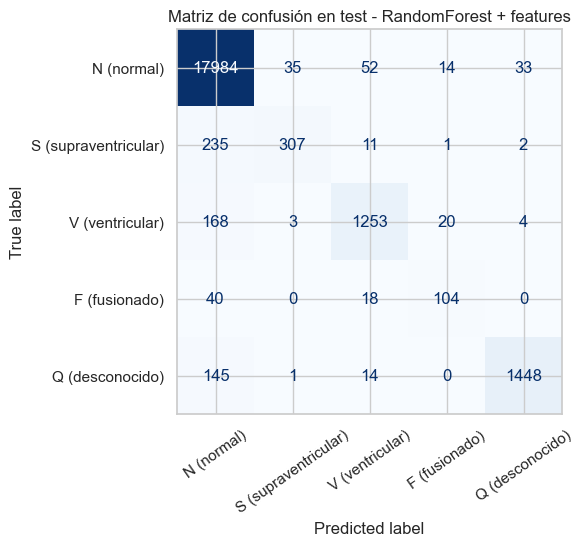

                      precision    recall  f1-score   support

          N (normal)       0.97      0.99      0.98     18118
S (supraventricular)       0.89      0.55      0.68       556
     V (ventricular)       0.93      0.87      0.90      1448
       F (fusionado)       0.75      0.64      0.69       162
     Q (desconocido)       0.97      0.90      0.94      1608

            accuracy                           0.96     21892
           macro avg       0.90      0.79      0.84     21892
        weighted avg       0.96      0.96      0.96     21892



In [52]:
plot_confusion(
    y_test,
    y_test_pred_best,
    title=f"Matriz de confusión en test - {best_model_name}"
)
print_report(y_test, y_test_pred_best)

## 17. Resumen final de métricas

En esta sección se recopilan los resultados obtenidos por los distintos modelos en validación y, posteriormente, el rendimiento del modelo seleccionado sobre `test`.

Esta tabla facilita una visión global del experimento y permite relacionar la elección final con métricas comparables entre iteraciones.

In [53]:
summary_results = pd.DataFrame(results).round(4)
summary_results

,modelo,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,Dummy - clase mayoritaria,val,0.8277,0.2000,0.1655,0.2000,0.1811
1,LogReg multinomial,val,0.6776,0.7787,0.4488,0.7787,0.4857
2,RandomForest + features,val,0.9653,0.8026,0.9059,0.8026,0.8468
3,MLP,val,0.9038,0.9279,0.6573,0.9279,0.7159
4,CNN 1D,val,0.9070,0.8914,0.6555,0.8914,0.7142
5,RandomForest + features,test,0.9636,0.7905,0.9014,0.7905,0.8368


## 18. Conclusiones finales

A partir de las iteraciones realizadas, el modelo que obtuvo el mejor rendimiento en validación fue **RandomForest + features**, con un `macro-F1` de **0.8468**. Por este motivo, se seleccionó como modelo final para su evaluación sobre el conjunto de test.

En test, el modelo mantuvo un comportamiento muy próximo al observado en validación, alcanzando un `macro-F1` de **0.8368** y una `accuracy` de **0.9636**. La proximidad entre ambos resultados sugiere una capacidad de generalización razonable, sin evidencias fuertes de sobreajuste en las configuraciones evaluadas.

El análisis por clases muestra un comportamiento desigual. Las clases **N**, **V** y **Q** presentan métricas altas y estables, mientras que las mayores dificultades se concentran en **S** y **F**, que además corresponden a categorías minoritarias. En particular, la clase **S** alcanza en test un `recall` de **0.55**, y la clase **F** un `recall` de **0.64**, lo que confirma que siguen siendo las más complejas dentro del problema planteado.

En conjunto, los resultados obtenidos indican que la clasificación de latidos ECG puede abordarse eficazmente como una tarea de clasificación supervisada multiclase. Además, en el marco de este experimento, el enfoque basado en extracción manual de características y `RandomForest` obtuvo un mejor rendimiento global que las arquitecturas profundas implementadas en esta práctica.

## 19. Discusión final sobre decisiones adoptadas

### Decisiones respaldadas por el enunciado y por el tipo de problema

La elección del caso de clasificación ECG, el planteamiento como tarea supervisada multiclase y la inclusión de análisis exploratorio, varias iteraciones de modelado y una comparación final entre enfoques son coherentes con los objetivos de la práctica.

### Decisiones metodológicas añadidas

Además, se incorporaron varias decisiones que refuerzan la consistencia metodológica del trabajo:

- conservar el conjunto de `test` exclusivamente para la evaluación final;
- generar una partición de validación estratificada a partir de `train`;
- priorizar `macro-F1` como criterio principal de selección;
- utilizar pesos por clase para mitigar parcialmente el desbalanceo;
- comparar modelos de distinta familia y complejidad.

### Valor de estas decisiones

Estas decisiones reducen el riesgo de extraer conclusiones sesgadas a partir de métricas poco representativas y facilitan una interpretación más realista del comportamiento de los modelos, especialmente en las clases minoritarias.

## 20. Posibles mejoras futuras

Las principales líneas de mejora se concentran en tres aspectos.

En primer lugar, convendría reforzar el tratamiento de las clases minoritarias, especialmente **S** y **F**, mediante estrategias como ajuste más fino de `class_weight`, sobremuestreo controlado o técnicas de aumentación sobre las señales.

En segundo lugar, sería recomendable realizar una exploración más sistemática de hiperparámetros, en particular en los modelos neuronales, ya que su rendimiento podría depender de forma importante de la arquitectura, la tasa de aprendizaje, el número de épocas o la regularización aplicada.

Por último, desde el punto de vista metodológico, sería conveniente reentrenar el modelo seleccionado utilizando todo el conjunto de entrenamiento original antes de la evaluación final, así como complementar la validación simple con esquemas más robustos, como validación cruzada estratificada.

## 21. Cierre

El notebook cubre los elementos principales de una resolución completa del problema: introducción, análisis exploratorio, justificación de decisiones, varias iteraciones de modelado, comparación cuantitativa, selección del mejor modelo y evaluación final sobre test.

En conjunto, el trabajo desarrolla una solución metodológicamente coherente para la clasificación de latidos ECG, mostrando tanto el rendimiento alcanzado como las limitaciones que todavía persisten en las clases minoritarias.